# Caso de aprobacion de tarjetas de credito 

Pamela Cerdas 


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold

In [2]:
mypath = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"

data = pd.read_csv(mypath, sep=" ", header=None)

data.columns = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','class']

print(data.shape)
data.head()

(690, 15)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,class
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [3]:
data['A4'].value_counts()

A4
2    525
1    163
3      2
Name: count, dtype: int64

In [4]:
data['A4'] = data['A4'].map({2:2, 1:0, 3:0})
data['A5'] = data['A5'].map({1:1,2:0,3:3,4:4,5:0,6:6,7:7,8:8,9:9,10:0,11:11,12:0,13:13,14:14})
data['A6'] = data['A6'].map({1:1,2:0,3:0,4:4,5:5,7:0,8:8,9:0})

In [5]:
data['A4'].value_counts()

A4
2    525
0    165
Name: count, dtype: int64

In [6]:
# Ahora sí, definamos nuestras variables de entrada y de salida, observa que ambas son DataFrames de Pandas:

X = data.iloc[:,:-1]  

Y = data.iloc[:,-1]     # También puede ser: data[['class']]

In [7]:
Xtv, Xtest, ytv, ytest = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=1)  
print(Xtv.shape, ': dimensión de datos de entrada para entrenamiento y validación')
print(Xtest.shape, ': dimensión de datos de entrada para prueba')  
print(ytv.shape, ': dimensión de variable de salida para entrenamiento y validación')
print(ytest.shape, ': dimensión de variable de salida para prueba')

(552, 14) : dimensión de datos de entrada para entrenamiento y validación
(138, 14) : dimensión de datos de entrada para prueba
(552,) : dimensión de variable de salida para entrenamiento y validación
(138,) : dimensión de variable de salida para prueba


In [8]:
ytv.sum()/ytv.shape[0]

np.float64(0.44565217391304346)

In [9]:
# Transformaciones a factores numéricos de entrada:
num_pipeline = Pipeline(steps = [('impMediana', SimpleImputer(strategy='median')),
                                 ('escalaNum', MinMaxScaler(feature_range=(1,2)))])   
num_pipeline_nombres = ['A2','A3','A7','A10','A13','A14']

# Transformaciones a factores categóricos de entrada:
catImp_pipeline = Pipeline(steps = [('impModa', SimpleImputer(strategy='most_frequent'))])  
catImp_pipeline_nombres = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']

catOHE_pipeline = Pipeline(steps = [('OneHotE', OneHotEncoder(drop='first'))])
catOHE_pipeline_nombres = [ 'A4','A5','A6','A12']


# Conjuntamos las transformaciones numéricas y categóricas que se estarán aplicando a los datos de entrada:
columnasTransformer = ColumnTransformer(transformers = [('numpipe', num_pipeline, num_pipeline_nombres),
                                                        ('catimp', catImp_pipeline, catImp_pipeline_nombres),
                                                        ('catohe', catOHE_pipeline, catOHE_pipeline_nombres)],
                                        remainder='passthrough')

In [10]:
def get_models():
  modelos = list()
  nombres = list()

  # LR - Regresión Logística:
  modelos.append(LogisticRegression(solver='liblinear'))
  nombres.append('LR')

  # DT - Árbol de Decisión:
  modelos.append(DecisionTreeClassifier())
  nombres.append('DT')
  
  # MLP - Red Neuronal Artificial / Perceptrón Lineal Multicapa:  
  modelos.append(MLPClassifier(hidden_layer_sizes=(30,), max_iter=3000))
  nombres.append('MLP')
  
  # SVM - Máquina de Vector Soporte:
  modelos.append(SVC(gamma='scale'))
  nombres.append('SVM')

  # kNN - k-Vecinos más cercanos:
  modelos.append(KNeighborsClassifier())
  nombres.append('kNN')
  
  return modelos, nombres

In [11]:
modelos, nombres = get_models()  # cargamos los modelos a comparar
resultados = list()   

for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])

  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=0)
  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv)


  resultados.append(scores)
  print('>> %s: %.3f (%.3f)' % (nombres[i], np.mean(scores), np.std(scores)))

>> LR: 0.861 (0.039)
>> DT: 0.816 (0.055)
>> MLP: 0.838 (0.036)
>> SVM: 0.850 (0.041)
>> kNN: 0.791 (0.040)


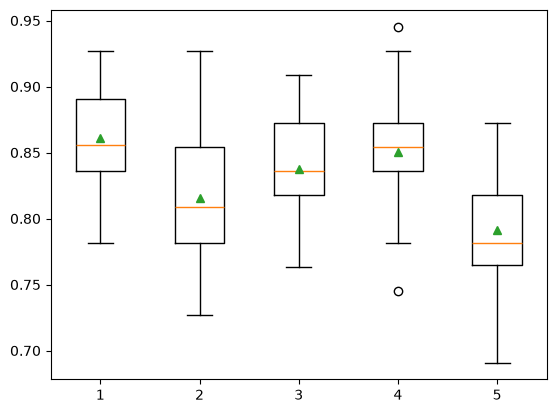

In [13]:
plt.boxplot(resultados, label=nombres, showmeans=True)
plt.show()

## Regresion logistica con regularizaciones 

In [17]:
def get_modelsRegs():
  modelos, nombres = list(), list()

  # LR - sin regularización:
  modelos.append(LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000, random_state=1))
  nombres.append('LR')

  # Lasso:
  modelos.append(LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, C=1., random_state=1))
  nombres.append('LASSO')
  
  # Ridge:
  modelos.append(LogisticRegression(penalty='l2', solver='liblinear', max_iter=2000, C=10.01, random_state=1))
  nombres.append('RIDGE')
  
  # Elastic-Net:
  modelos.append(LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=4000, C=1., random_state=1))
  nombres.append('EN')

  return modelos, nombres

## Entrenar y validar 

c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead 

>> LR 0.868 (0.051)


c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty'

>> LASSO 0.867 (0.046)


c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead 

>> RIDGE 0.869 (0.048)


c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead 

>> EN 0.863 (0.048)


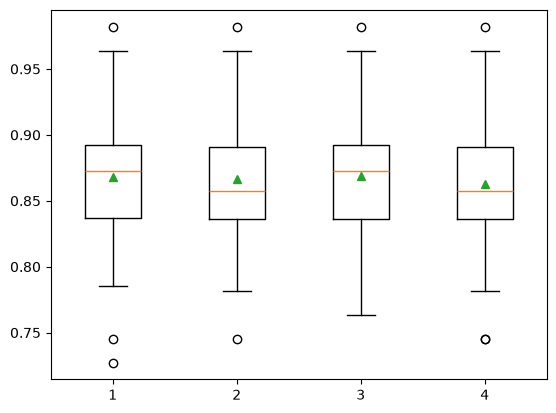

In [18]:
modelos, nombres = get_modelsRegs()

resultados = list() 

 

for i in range(len(modelos)):

 

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])

 

  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=8)

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv)

 

  resultados.append(scores)

  print('>> %s %.3f (%.3f)' % (nombres[i], np.mean(scores), np.std(scores)))

 

 

plt.boxplot(resultados, label=nombres, showmeans=True)

plt.show()

La regresion con regularización utiliza la comparacion de varios modelos cruzandolos de manera repetida, ahora bien, estos modelos de precisión muestran niveles simaleres entre ellos, mostrando valores que rondan el 86%. En el Boxplot se evicencia de manera estadistica que la variabilidad es reducida por ende muestran comportamientos estables. 

## Fine Tuning (Ajuste final)

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix  

In [20]:
# RIDGE - métrica L2:

 

modelo = LogisticRegression(penalty='l2', max_iter=10000, random_state=1)

 

dicc_grid = {'C':[0.0001,0.01,0.1,1.0,10.,100.],

             'solver':['newton-cg','lbfgs','liblinear','sag','saga']

             }

 

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=8)

 

grid = GridSearchCV(estimator=modelo, 

                    param_grid=dicc_grid, 

                    cv=cv, 

                    scoring='accuracy')

In [21]:
# Transformamos los datos de entrada:

Xx = columnasTransformer.fit_transform(Xtv)

 

# Llevamos a cabo el proceso de etrenamiento con validación-cruzada y búsqueda de malla.

# Observa que de acuerdo a las opciones incluidas en la malla, se estarán realizando (6)(5)=30 

# combinaciones diferentes, además de las (10)(5)=50 particiones de la validación-cruzada,

# lo cual implica también un mayor tiempo de entrenamiento.

 

grid.fit(Xx, np.ravel(ytv))

 

print('Mejor valor de exactitud obtenido con la mejor combinación:', grid.best_score_)

print('Mejor combinación de valores encontrados de los hiperparámetros:', grid.best_params_)

print('Métrica utilizada:', grid.scoring)

c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead 

Mejor valor de exactitud obtenido con la mejor combinación: 0.8695389610389609
Mejor combinación de valores encontrados de los hiperparámetros: {'C': 100.0, 'solver': 'liblinear'}
Métrica utilizada: accuracy


c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Este modelo obtiene el mejor valor de exactitud con un 86% paso de un 81 a 86

### Modelo final con el conjunto de pruebas 

In [22]:
modelo = LogisticRegression(penalty='l2', 

                            max_iter=10000,

                            C=100.0,

                            solver='liblinear',

                            random_state=1)

 

# Entrenamos el modelo por última vez con los datos de entrenamiento y validación conjuntos:

Xct = columnasTransformer.fit(Xtv)

Xxt = Xct.transform(Xtv)

modelo.fit(Xxt, np.ravel(ytv))

 

# Transformamos los datos de prueba y los utilizamos por primera vez para obtener sus predicciones

# y desempeño del modelo:

 

Xxtest = Xct.transform(Xtest)

print(modelo.score(Xxtest, np.ravel(ytest)))

0.8405797101449275


c:\Users\Usuario\Documents\Introducción a Machine Learning\Learnig curvas de aprendizaje\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [24]:
pp = modelo.predict(Xxtest)

cm = confusion_matrix(ytest, pp)

print(cm)

[[61 16]
 [ 6 55]]


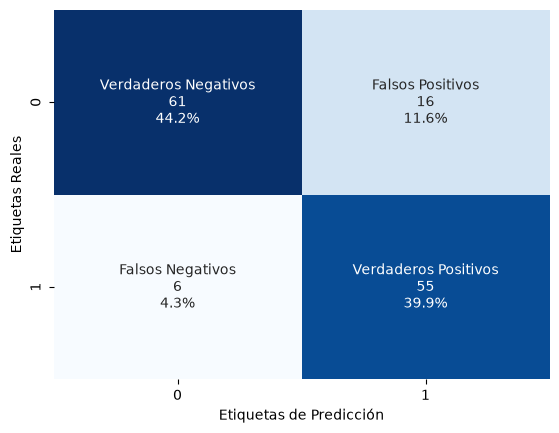

In [25]:
txt = ['Verdaderos Negativos','Falsos Positivos','Falsos Negativos','Verdaderos Positivos']

frecuencia = ["{0:0.0f}".format(value) for value in cm.flatten()]

porcentaje = ["{0:.1%}".format(value) for value in cm.flatten()/np.sum(cm)]

 

labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(txt,frecuencia,porcentaje)]

labels = np.asarray(labels).reshape(2,2)

 

ax = sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False)

ax.set(ylabel="Etiquetas Reales", xlabel="Etiquetas de Predicción")

plt.show()